## Day 14 – Evaluation

In [1]:
# Standalone setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from scipy.signal import wiener
from scipy.fft import fft, ifft

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12

smi_daily = yf.download("^SSMI", period="1y", interval="1d", progress=False)
if isinstance(smi_daily.columns, pd.MultiIndex):
    smi_daily.columns = smi_daily.columns.get_level_values(0)

price = smi_daily['Close'].dropna().values.astype(float)
time_index = smi_daily['Close'].dropna().index
N = len(price)

# Standalone functions and variables
def manual_convolve(signal, kernel, boundary='zero'):
    N = len(signal)
    M = len(kernel)
    half = M // 2
    padded = np.zeros(N + M - 1)
    padded[half:half + N] = signal
    output = np.zeros(N)
    for n in range(N):
        total = 0.0
        for k in range(M):
            total += kernel[k] * padded[n + M - 1 - k]
        output[n] = total
    return output

def create_moving_average_kernel(size):
    return np.ones(size) / size

def create_gaussian_kernel(size, sigma=None):
    if sigma is None:
        sigma = size / 6.0
    center = size // 2
    kernel = np.array([np.exp(-0.5 * ((k - center) / sigma)**2) for k in range(size)])
    return kernel / np.sum(kernel)

def wiener_deconvolution(filtered_signal, kernel, regularization=0.01):
    n = len(filtered_signal)
    kernel_padded = np.zeros(n)
    kernel_padded[:len(kernel)] = kernel
    Y = fft(filtered_signal)
    H = fft(kernel_padded)
    H_conj = np.conj(H)
    G = H_conj / (np.abs(H)**2 + regularization)
    X_hat = G * Y
    return np.real(ifft(X_hat))

/var/folders/qr/40kwqhb578jfzhtt2nw831h40000gn/T/ipykernel_24517/1732571381.py:13: FutureWarning: YF.download() has changed argument auto_adjust default to True
  smi_daily = yf.download("^SSMI", period="1y", interval="1d", progress=False)


### Evaluation Approach Definition

> **Metric 1 – RMSE (Root Mean Squared Error):** Quantifies the point-wise amplitude deviation between the original signal and the filtered/reconstructed versions in CHF. RMSE is appropriate because the use case requires accurate amplitude representation for risk assessment.

> **Metric 2 – Peak Preservation Ratio:** Defined as $\text{PPR} = |\text{max}(y) - \text{min}(y)| / |\text{max}(x) - \text{min}(x)|$, where $x$ is the original and $y$ is the filtered/reconstructed signal. This metric captures how well the dynamic range (transient peaks and drawdowns) is preserved, which is critical for risk monitoring.

### Evaluation Comparison Execution

> The influence of key parameters **kernel size M, kernel type, and Wiener regularization λ** was evaluated using RMSE and Peak Preservation Ratio. These parameters directly affect smoothing strength and reconstruction fidelity, which are critical for the trade-off between noise reduction and feature preservation in financial risk monitoring.

In [2]:
def compute_peak_preservation(original, processed):
    """Compute peak preservation ratio."""
    orig_range = np.max(original) - np.min(original)
    proc_range = np.max(processed) - np.min(processed)
    return proc_range / orig_range if orig_range > 0 else 0

# Systematic kernel size variation
kernel_sizes = [3, 5, 10, 20]
regularizations = [0.001, 0.01, 0.1, 1.0]

eval_results = []
baseline_rmse_filt = None

for M in kernel_sizes:
    kernel = create_moving_average_kernel(M)
    filtered = manual_convolve(price, kernel)
    
    rmse_filt = np.sqrt(np.mean((price - filtered)**2))
    ppr_filt = compute_peak_preservation(price, filtered)
    
    if M == 5:
        baseline_rmse_filt = rmse_filt
    
    eval_results.append({
        'Configuration': f'MA, M={M} (filtered)',
        'RMSE (CHF)': rmse_filt,
        'Peak Preservation': ppr_filt,
        'Type': 'Filtered'
    })

# Gaussian comparison at M=5
g_kernel = create_gaussian_kernel(5)
filtered_gauss = manual_convolve(price, g_kernel)
eval_results.append({
    'Configuration': 'Gaussian, M=5 (filtered)',
    'RMSE (CHF)': np.sqrt(np.mean((price - filtered_gauss)**2)),
    'Peak Preservation': compute_peak_preservation(price, filtered_gauss),
    'Type': 'Filtered'
})

# Deconvolution parameter sweep (using MA, M=5 as baseline kernel)
baseline_kernel = create_moving_average_kernel(5)
baseline_filtered = manual_convolve(price, baseline_kernel)

for lam in regularizations:
    recon = wiener_deconvolution(baseline_filtered, baseline_kernel, lam)
    rmse_recon = np.sqrt(np.mean((price - recon)**2))
    ppr_recon = compute_peak_preservation(price, recon)
    eval_results.append({
        'Configuration': f'Wiener recon, λ={lam}',
        'RMSE (CHF)': rmse_recon,
        'Peak Preservation': ppr_recon,
        'Type': 'Reconstructed'
    })

eval_df = pd.DataFrame(eval_results)
if baseline_rmse_filt and baseline_rmse_filt > 0:
    eval_df['RMSE Change vs Baseline (%)'] = (
        (eval_df['RMSE (CHF)'] - baseline_rmse_filt) / baseline_rmse_filt * 100
    )
else:
    eval_df['RMSE Change vs Baseline (%)'] = 0

print(eval_df[['Configuration', 'RMSE (CHF)', 'Peak Preservation', 'RMSE Change vs Baseline (%)']]
      .to_markdown(index=False, floatfmt='.4f'))

| Configuration            |   RMSE (CHF) |   Peak Preservation |   RMSE Change vs Baseline (%) |
|:-------------------------|-------------:|--------------------:|------------------------------:|
| MA, M=3 (filtered)       |     387.1925 |              1.7564 |                      -26.0318 |
| MA, M=5 (filtered)       |     523.4583 |              2.0359 |                        0.0000 |
| MA, M=10 (filtered)      |     767.3960 |              2.3950 |                       46.6012 |
| MA, M=20 (filtered)      |    1082.2955 |              2.4170 |                      106.7587 |
| Gaussian, M=5 (filtered) |     304.3981 |              1.4603 |                      -41.8486 |
| Wiener recon, λ=0.001    |    1846.4943 |              3.7762 |                      252.7491 |
| Wiener recon, λ=0.01     |    1048.0859 |              3.2360 |                      100.2234 |
| Wiener recon, λ=0.1      |    1324.7961 |              1.9796 |                      153.0853 |
| Wiener recon, λ=1.

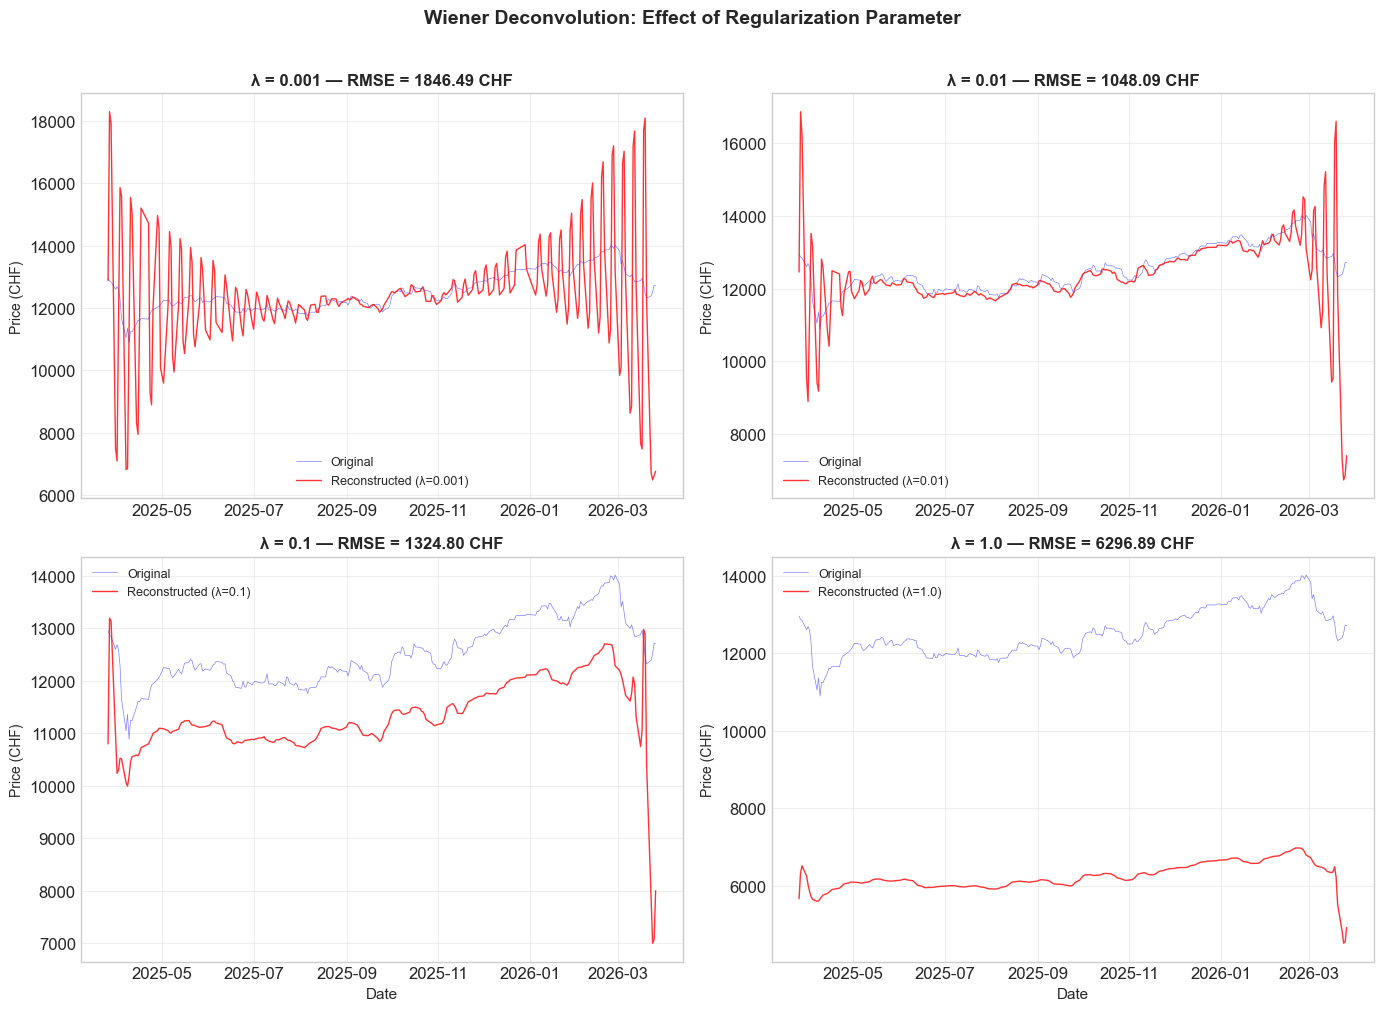

In [3]:
# Visualization: Effect of regularization on reconstruction
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

baseline_kernel = create_moving_average_kernel(5)
baseline_filtered = manual_convolve(price, baseline_kernel)

for i, lam in enumerate(regularizations):
    ax = axes[i // 2, i % 2]
    recon = wiener_deconvolution(baseline_filtered, baseline_kernel, lam)
    rmse = np.sqrt(np.mean((price - recon)**2))
    
    ax.plot(time_index, price, 'b-', linewidth=0.5, alpha=0.5, label='Original')
    ax.plot(time_index, recon, 'r-', linewidth=1, alpha=0.8,
            label=f'Reconstructed (λ={lam})')
    ax.set_title(f'λ = {lam} — RMSE = {rmse:.2f} CHF', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_ylabel('Price (CHF)', fontsize=10)

axes[1, 0].set_xlabel('Date', fontsize=11)
axes[1, 1].set_xlabel('Date', fontsize=11)
plt.suptitle('Wiener Deconvolution: Effect of Regularization Parameter',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()